# Chiron Basecalling — Descriptive Analysis of 5 Test Reads (Track 1)

This notebook analyzes the FASTQ output produced by running [Chiron](https://github.com/haotianteng/Chiron) (a CNN + biLSTM + CTC deep learning basecaller for Oxford Nanopore raw signal data) on the 5 bundled example DNA reads, using the CPU-only Docker setup documented in [`Chiron_CPU_Setup_Guide.ipynb`](./Chiron_CPU_Setup_Guide.ipynb).

This is a **descriptive analysis** (no reference genome required) ,it characterizes what Chiron actually produced (read length, per-base confidence, base composition), rather than measuring basecalling *accuracy* against ground truth (which would require a reference genome for these specific reads;

> **Reproducibility note:**  To reproduce these exact results, place the 5 `.fastq` files (`read1.fastq` ... `read5.fastq`) in a folder named `results/` next to this notebook, and run all cells. The outputs shown below were generated from that same data and are saved directly in this notebook, so they display correctly on GitHub even without re-running anything.


## Setup: imports and analysis functions



In [1]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO

FASTQ_FOLDER = "results"  # folder containing read1.fastq ... read5.fastq, next to this notebook


def load_reads(fastq_folder):
    """Return a dict of {read_id: SeqRecord} for every .fastq file in the folder."""
    records = {}
    for path in sorted(glob.glob(os.path.join(fastq_folder, "*.fastq"))):
        for rec in SeqIO.parse(path, "fastq"):
            records[rec.id] = rec
    return records


def compute_summary(records):
    """Compute per-read length, mean Phred quality, and GC content."""
    rows = []
    for read_id, rec in records.items():
        seq = str(rec.seq).upper()
        length = len(seq)
        quals = rec.letter_annotations["phred_quality"]
        mean_q = sum(quals) / len(quals) if quals else 0.0
        gc_pct = 100 * (seq.count("G") + seq.count("C")) / length if length else 0.0
        rows.append({
            "read_id": read_id,
            "length_bp": length,
            "mean_phred_quality": round(mean_q, 2),
            "gc_content_pct": round(gc_pct, 2),
        })
    return rows


def plot_read_lengths(rows):
    ids = [r["read_id"] for r in rows]
    lengths = [r["length_bp"] for r in rows]
    plt.figure(figsize=(7, 4))
    plt.bar(ids, lengths, color="#4C72B0")
    plt.xlabel("Read"); plt.ylabel("Length (bp)")
    plt.title("Basecalled read length per read")
    plt.tight_layout(); plt.show()


def plot_per_base_quality(records):
    plt.figure(figsize=(9, 5))
    for read_id, rec in records.items():
        quals = rec.letter_annotations["phred_quality"]
        plt.plot(range(1, len(quals) + 1), quals, label=read_id, alpha=0.8, linewidth=1)
    plt.xlabel("Position in read (bp)"); plt.ylabel("Phred quality score")
    plt.title("Per-base basecalling confidence (Phred quality) per read")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()


def plot_base_composition(records):
    ids = list(records.keys())
    bases = ["A", "C", "G", "T"]
    counts = {b: [] for b in bases}
    for read_id in ids:
        seq = str(records[read_id].seq).upper()
        length = len(seq)
        for b in bases:
            counts[b].append(100 * seq.count(b) / length if length else 0.0)
    bottom = [0] * len(ids)
    colors = {"A": "#55A868", "C": "#C44E52", "G": "#4C72B0", "T": "#8172B2"}
    plt.figure(figsize=(7, 4))
    for b in bases:
        plt.bar(ids, counts[b], bottom=bottom, label=b, color=colors[b])
        bottom = [bottom[i] + counts[b][i] for i in range(len(ids))]
    plt.xlabel("Read"); plt.ylabel("Base composition (%)")
    plt.title("A/C/G/T composition per basecalled read")
    plt.legend(title="Base"); plt.tight_layout(); plt.show()


records = load_reads(FASTQ_FOLDER)
summary = compute_summary(records) if records else []
print(f"Loaded {len(records)} reads from '{FASTQ_FOLDER}/'")

Loaded 5 reads from 'results/'


## Summary table

In [2]:
pd.DataFrame(summary)

,read_id,length_bp,mean_phred_quality,gc_content_pct
0,read1,2550,5.06,64.9
1,read2,6742,5.01,68.67
2,read3,5775,5.35,60.87
3,read4,15020,5.29,62.87
4,read5,11837,5.43,63.56


## 1. Read length per read

Basecalled read lengths ranged from **2,550 bp** (read1) to **15,020 bp** (read4) — a roughly 6x spread across just 5 reads, reflecting natural variability in DNA fragment length during nanopore sequencing (not a Chiron artifact).

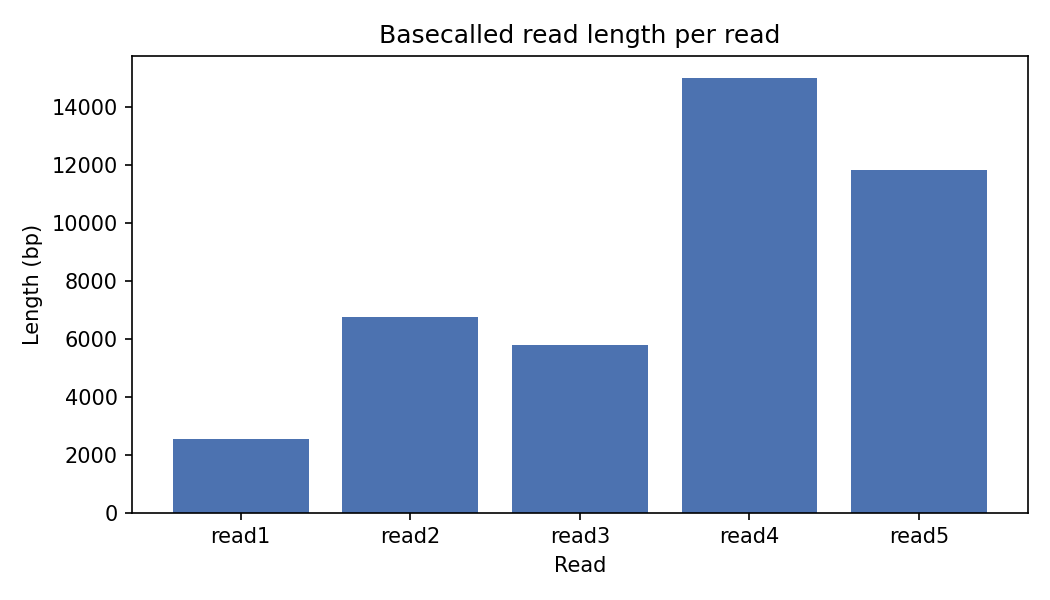

In [3]:
plot_read_lengths(summary)

## 2. Per-base basecalling confidence (Phred quality)

This plot is the closest analogue to **Figure 2** in the original Chiron paper, which visualizes the model's per-position base probability curve. Here, each read's per-base Phred quality score is plotted across its length.

**Observation:** mean Phred quality across all 5 reads sits in the **~5.0–5.4** range (see summary table above) — noticeably low confidence (Phred 5 ≈ ~32% estimated error probability per base) compared to the accuracy Chiron reports in the original paper (identity rates of 87–91% on its benchmark datasets, Table 1). A few plausible explanations worth investigating further:
- The bundled example `.fast5` files are very old (sourced from the `nanonet` project) and may differ in signal characteristics from the R9.4 flowcell data Chiron was actually trained/validated on in the paper.
- We used the pretrained `DNA_default` model as-is, with default `dna-pre` preset parameters — no fine-tuning or preprocessing tuned to this specific data.
- The `read_id`/extraction compatibility patch applied to run this data (see setup guide) only fixes metadata extraction, not necessarily every aspect of raw signal normalization.



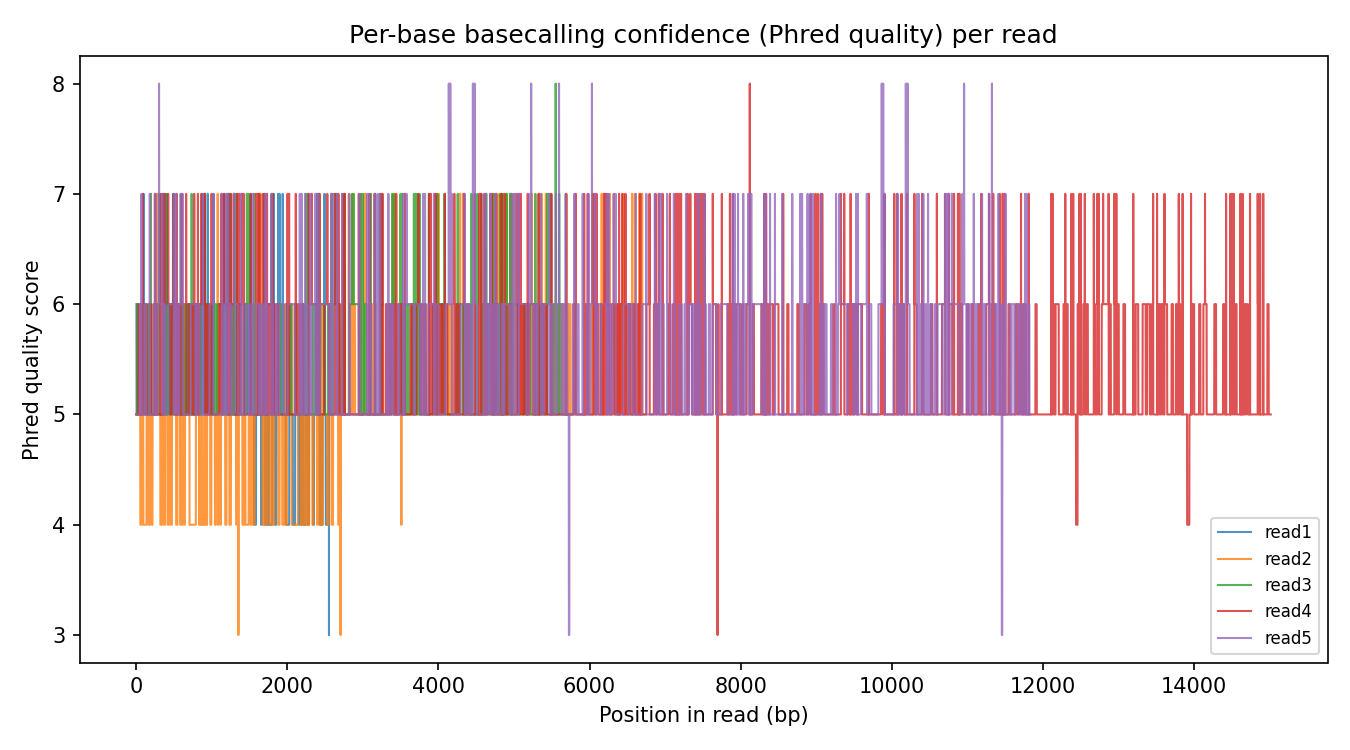

In [4]:
plot_per_base_quality(records)

## 3. Base composition (A/C/G/T)

GC content across the 5 reads ranges from **60.9% to 68.7%** — all reads are noticeably GC-skewed rather than the ~50% roughly-balanced composition typical of many genomes. This could reflect the actual GC content of the source organism these reads were sequenced from (unconfirmed, since the specific species/genome for these example reads is not documented in the Chiron repo), or could indicate a systematic basecalling bias. This would be worth cross-checking in a Track 2 (reference-alignment) analysis.

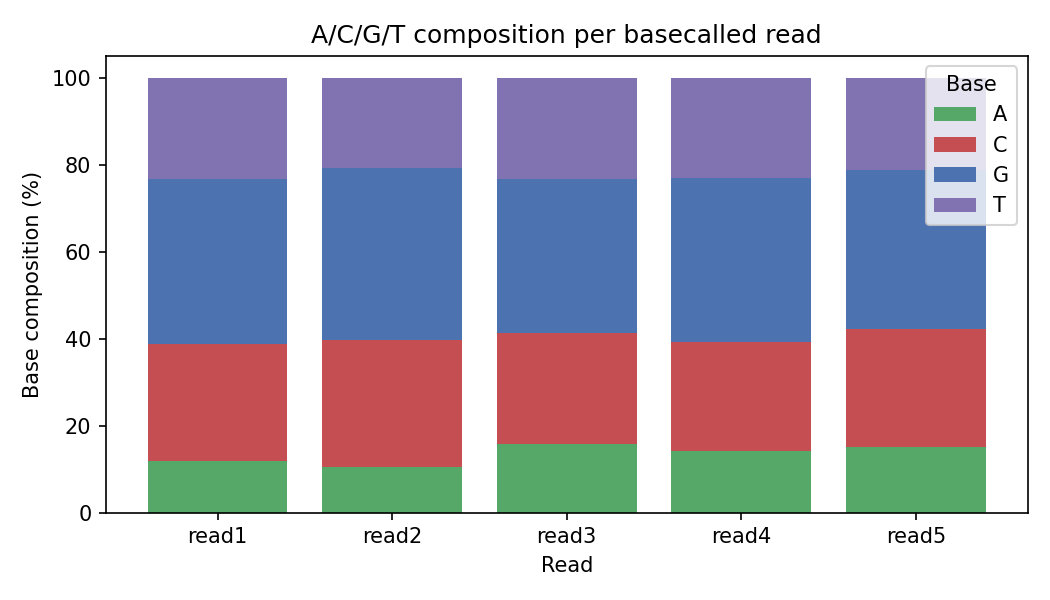

In [5]:
plot_base_composition(records)

## Summary

| Read | Length (bp) | Mean Phred Quality | GC Content (%) |
|---|---|---|---|
| read1 | 2,550 | 5.06 | 64.90 |
| read2 | 6,742 | 5.01 | 68.67 |
| read3 | 5,775 | 5.35 | 60.87 |
| read4 | 15,020 | 5.29 | 62.87 |
| read5 | 11,837 | 5.43 | 63.56 |

Chiron successfully basecalled all 5 example reads end-to-end (raw signal → CNN → biLSTM → CTC decode → FASTQ), confirming the CPU installation is functionally correct. Read lengths and base composition look like plausible DNA output; however, the relatively low per-base Phred quality scores suggest either a data/model mismatch specific to these legacy example files, or genuinely lower-confidence calls that would need reference-genome alignment (Track 2) to properly quantify as an actual identity/mismatch/indel rate, following the same methodology as Table 1 in the original paper.
